# §4 · Black-Litterman-Modell
**Bachelorarbeit: Kritik des CAPM und Erweiterung durch das Black-Litterman-Modell**  
Lucas Posern · TU Dresden · 2026

> LaTeX: `BLM.tex`

| Abschnitt | Inhalt |
|---|---|
| §4.5 | BLM-Backtest: Szenario A (korrekte Views) vs. Szenario B (falsche Views) |
| §4.6.1 | Parametersensitivität (τ, c) |
| §4.6.2 | Normalverteilungsannahme & Fat Tails |

Läuft vollständig offline, ohne Internetzugang.

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

ROOT = Path(os.path.abspath(''))
CORE = ROOT / 'core'
DATA = ROOT / 'data'
if str(CORE) not in sys.path:
    sys.path.insert(0, str(CORE))

from data_loader import IDZOREK_W_EQ  # Gleichgewichtsgewichte (Idzorek 2004)
from covariance import sample_cov, ledoit_wolf_cov
from views import ViewSet
from black_litterman import run_blm, implied_risk_aversion, implied_returns
from portfolio_metrics import performance_summary, cumulative_returns

plt.rcParams.update({
    'figure.dpi': 130, 'figure.figsize': (9, 4.5),
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'legend.fontsize': 10, 'lines.linewidth': 1.8,
})
C = ['#1f4e79', '#c00000', '#538135', '#7030a0', '#833c00', '#005073']
from IPython.display import display
print('Setup abgeschlossen.')

Setup abgeschlossen.


---
## §4.5 · BLM-Backtest: Szenario A (korrekte Views) vs. Szenario B (falsche Views)

Idzorek-Multi-Asset-Universum · Train: Jan 2008-Dez 2018 · Test: Jan 2019-Dez 2024

| Szenario | Views | Erwartung |
|---|---|---|
| **A - korrekte Views** | Aktien > Anleihen (+5%), IWF > IWD (+4%), US > Intl. Dev. (+2%) | tatsächliche Outperformer der Testperiode |
| **B - falsche Views** | Anleihen > Aktien (+3%), IWD > IWF (+3%), EFA > US (+3%) | gespiegelte Richtungen, systematisch falsch |

In [2]:
# Konstanten
TICKERS = ["AGG", "BWX", "IWF", "IWD", "IWO", "IWN", "EFA", "EEM"]
LABELS  = {
    "AGG": "US Bonds (AGG)",        "BWX": "Intl Bonds (BWX)",
    "IWF": "US Lg Growth (IWF)",    "IWD": "US Lg Value (IWD)",
    "IWO": "US Sm Growth (IWO)",    "IWN": "US Sm Value (IWN)",
    "EFA": "Intl Dev (EFA)",        "EEM": "Emg Mkts (EEM)",
}
SHORT = {t: v.split(" (")[0] for t, v in LABELS.items()}
# Gleichgewichtsgewichte: globales Marktportfolio (Idzorek et al.), Trainingsstart 2008
_eq_file = DATA / "eq_weights_train_start.csv"
if _eq_file.exists():
    _eq_df    = pd.read_csv(_eq_file, index_col=0)
    W_EQ_DICT = _eq_df["w_eq"].reindex(TICKERS).to_dict()
    print("w_eq: Idzorek-Marktportfolio-Gewichte (2008) geladen.")
else:
    print("WARNUNG: eq_weights_train_start.csv nicht gefunden \u2192 Idzorek-Fallback")
    _W_EQ_RAW = {"AGG": 0.1934, "BWX": 0.2613, "IWF": 0.1209, "IWD": 0.1209,
                 "IWO": 0.0134, "IWN": 0.0134, "EFA": 0.2418, "EEM": 0.0349}
    _total    = sum(_W_EQ_RAW.values())
    W_EQ_DICT = {k: v / _total for k, v in _W_EQ_RAW.items()}
TAU = 0.05

# Daten laden (offline)
# ETF-Renditen (via yfinance vorheruntergeladen)
returns_all = pd.read_csv(DATA / "etf_returns_monthly.csv", index_col=0, parse_dates=True)
returns_all.index = pd.to_datetime(returns_all.index).to_period("M").to_timestamp("M")
returns_all = returns_all.loc[:, TICKERS].dropna()

# Risk-Free Rate (^IRX)
_rf = pd.read_csv(DATA / "rf_monthly.csv", index_col=0, parse_dates=True)
rf_all = _rf.iloc[:, 0] if isinstance(_rf, pd.DataFrame) else _rf
rf_all.index = pd.to_datetime(rf_all.index).to_period("M").to_timestamp("M")
rf_all = rf_all.reindex(returns_all.index).ffill()

# S&P-500 Excess Returns (^GSPC - rf)
_mkt = pd.read_csv(DATA / "spx_returns_monthly.csv", index_col=0, parse_dates=True)
mkt_all = _mkt.iloc[:, 0] if isinstance(_mkt, pd.DataFrame) else _mkt
mkt_all.index = pd.to_datetime(mkt_all.index).to_period("M").to_timestamp("M")
mkt_all = mkt_all.reindex(returns_all.index).ffill()

train_mask = (returns_all.index >= "2008-01-01") & (returns_all.index <= "2018-12-31")
test_mask  = (returns_all.index >= "2019-01-01") & (returns_all.index <= "2024-12-31")

returns_train = returns_all.loc[train_mask]
rf_train      = rf_all.loc[train_mask]
mkt_train     = mkt_all.loc[train_mask]
excess_train  = returns_train.sub(rf_train, axis=0)
returns_test  = returns_all.loc[test_mask]
rf_test       = rf_all.loc[test_mask]
assets        = list(returns_train.columns)

print(f"Train: {returns_train.index[0].date()} - {returns_train.index[-1].date()} ({len(returns_train)} Monate)")
print(f"Test:  {returns_test.index[0].date()} - {returns_test.index[-1].date()} ({len(returns_test)} Monate)")

# Modell-Parameter
Sigma = sample_cov(excess_train, annualize=True, frequency="M")
delta = implied_risk_aversion(mkt_train, annualize=True, frequency="M")
w_eq  = pd.Series(W_EQ_DICT).reindex(assets)
w_eq  = w_eq / w_eq.sum()
pi    = implied_returns(Sigma, w_eq, delta)
print(f"delta = {delta:.4f}, tau = {TAU}")

w_eq: Idzorek-Marktportfolio-Gewichte (2008) geladen.
Train: 2008-01-31 - 2018-12-31 (132 Monate)
Test:  2019-01-31 - 2024-12-31 (72 Monate)
delta = 2.4437, tau = 0.05


In [3]:
# Views Szenario A: korrekte Views
def make_views_A(asset_names, confidence=0.50):
    vs = ViewSet(asset_names=asset_names)
    vs.add_relative(outperform=["IWF","IWD","IWO","IWN","EFA","EEM"], underperform=["AGG","BWX"],
                    expected_diff=0.05, confidence=confidence,
                    label="Aktien > Anleihen: +5% p.a.")
    vs.add_relative(outperform=["IWF"], underperform=["IWD"],
                    expected_diff=0.04, confidence=confidence,
                    label="US Growth > US Value (IWF > IWD): +4% p.a.")
    vs.add_relative(outperform=["IWF","IWD"], underperform=["EFA"],
                    expected_diff=0.02, confidence=confidence,
                    label="US > Intl. Dev. (IWF/IWD > EFA): +2% p.a.")
    return vs

# Views Szenario B: falsche Views (gespiegelt)
def make_views_B(asset_names, confidence=0.50):
    vs = ViewSet(asset_names=asset_names)
    vs.add_relative(outperform=["AGG","BWX"], underperform=["IWF","IWD","IWO","IWN","EFA","EEM"],
                    expected_diff=0.03, confidence=confidence,
                    label="Anleihen > Aktien: +3% p.a. (FALSCH)")
    vs.add_relative(outperform=["IWD"], underperform=["IWF"],
                    expected_diff=0.03, confidence=confidence,
                    label="US Value > US Growth (IWD > IWF): +3% p.a. (FALSCH)")
    vs.add_relative(outperform=["EFA"], underperform=["IWF","IWD"],
                    expected_diff=0.03, confidence=confidence,
                    label="Intl. Dev. > US (EFA > IWF/IWD): +3% p.a. (FALSCH)")
    return vs

# BLM + Naiv berechnen
def run_scenario_full(views_fn, label, confidence_bl=0.50):
    exc_test = returns_test.sub(rf_test, axis=0)
    # Naiv (c -> 1, Prior komplett durch Views überschrieben)
    vs_n = views_fn(assets, confidence=0.9999)
    P_n, Q_n, Om_n = vs_n.build(Sigma=Sigma, tau=TAU, omega_method="idzorek")
    res_n  = run_blm(Sigma, w_eq, P_n, Q_n, Om_n, delta=delta, tau=TAU)
    ret_n  = (exc_test * res_n["w_BL"]).sum(axis=1).rename(f"Naiv {label}")
    # BLM (c = 0.50)
    vs = views_fn(assets, confidence=confidence_bl)
    P, Q, Om = vs.build(Sigma=Sigma, tau=TAU, omega_method="idzorek")
    res_bl = run_blm(Sigma, w_eq, P, Q, Om, delta=delta, tau=TAU)
    ret_bl = (exc_test * res_bl["w_BL"]).sum(axis=1).rename(f"BLM {label}")
    ret_eq = (exc_test * w_eq).sum(axis=1).rename("CAPM Baseline")
    return {
        "w_naiv": res_n["w_BL"], "mu_naiv": res_n["mu_BL"],
        "w_BL":   res_bl["w_BL"], "mu_BL":   res_bl["mu_BL"],
        "ret_naiv": ret_n, "ret_bl": ret_bl, "ret_eq": ret_eq,
    }

res_A = run_scenario_full(make_views_A, "Szenario A")
res_B = run_scenario_full(make_views_B, "Szenario B")

portfolios = {
    "CAPM Baseline":          res_A["ret_eq"],
    "Naiv A (korrekte Views)": res_A["ret_naiv"],
    "BLM A (korrekte Views)":  res_A["ret_bl"],
    "Naiv B (falsche Views)":  res_B["ret_naiv"],
    "BLM B (falsche Views)":   res_B["ret_bl"],
}
perf = performance_summary(portfolios, frequency=12)
pp   = perf.copy()
for col in ["Ann. Return", "Ann. Volatility", "Max Drawdown", "Total Return"]:
    if col in pp.columns: pp[col] *= 100
print("Performance (Test Jan 2019 - Dez 2024):")
print(pp.round(2))

Performance (Test Jan 2019 - Dez 2024):
                         Ann. Return  Ann. Volatility  Sharpe Ratio  \
Portfolio                                                             
CAPM Baseline                   3.85            12.16          0.32   
Naiv A (korrekte Views)        63.49            65.81          0.96   
BLM A (korrekte Views)         31.55            33.22          0.95   
Naiv B (falsche Views)        -49.47            47.00         -1.05   
BLM B (falsche Views)         -20.98            22.74         -0.92   

                         Max Drawdown  Total Return  
Portfolio                                            
CAPM Baseline                  -24.78         20.51  
Naiv A (korrekte Views)        -85.37       1094.99  
BLM A (korrekte Views)         -59.98        371.53  
Naiv B (falsche Views)         -97.48        -97.68  
BLM B (falsche Views)          -75.84        -76.07  


In [4]:
# Numerische Werte zu den Abbildungen: Tab. 4.1 (Erwartungsrenditen) & Tab. 4.2 (Gewichte)
tab_mu = pd.DataFrame({
    "pi":          pi,
    "mu_naiv_A":   res_A["mu_naiv"], "mu_BL_A": res_A["mu_BL"],
    "mu_naiv_B":   res_B["mu_naiv"], "mu_BL_B": res_B["mu_BL"],
}) * 100
print("Tab. 4.1 - Annualisierte Excess-Erwartungsrenditen (%):")
print(tab_mu.round(2).to_string())

tab_w = pd.DataFrame({
    "w_eq":       w_eq,
    "w_naiv_A":   res_A["w_naiv"], "w_BL_A": res_A["w_BL"],
    "w_naiv_B":   res_B["w_naiv"], "w_BL_B": res_B["w_BL"],
}) * 100
print()
print("Tab. 4.2 - Portfoliogewichte (%):")
print(tab_w.round(1).to_string())

Tab. 4.1 - Annualisierte Excess-Erwartungsrenditen (%):
       pi  mu_naiv_A  mu_BL_A  mu_naiv_B  mu_BL_B
AGG  0.30      -0.38    -0.01       1.02     0.63
BWX  1.58      -0.61     0.55       2.68     2.04
IWF  3.63       6.55     4.93      -3.10     0.35
IWD  3.64       2.55     2.97      -0.10     1.83
IWO  4.21       7.19     5.48      -4.00     0.24
IWN  4.03       3.56     3.62      -1.28     1.49
EFA  4.85       2.55     3.68       1.40     3.03
EEM  5.46       4.66     4.99       0.18     2.76

Tab. 4.2 - Portfoliogewichte (%):
     w_eq  w_naiv_A  w_BL_A  w_naiv_B  w_BL_B
AGG  19.3      -1.2    10.4      70.3    42.6
BWX  26.1       5.3    16.8      76.8    49.1
IWF  12.1     545.0   264.0    -392.7  -178.1
IWD  12.1    -327.1  -153.6     255.6   132.6
IWO   1.3       7.8     4.0     -16.0    -6.8
IWN   1.3       7.8     4.0     -16.0    -6.8
EFA  24.2    -152.2   -56.3     131.3    67.4
EEM   3.5       9.9     6.0     -14.0    -4.7


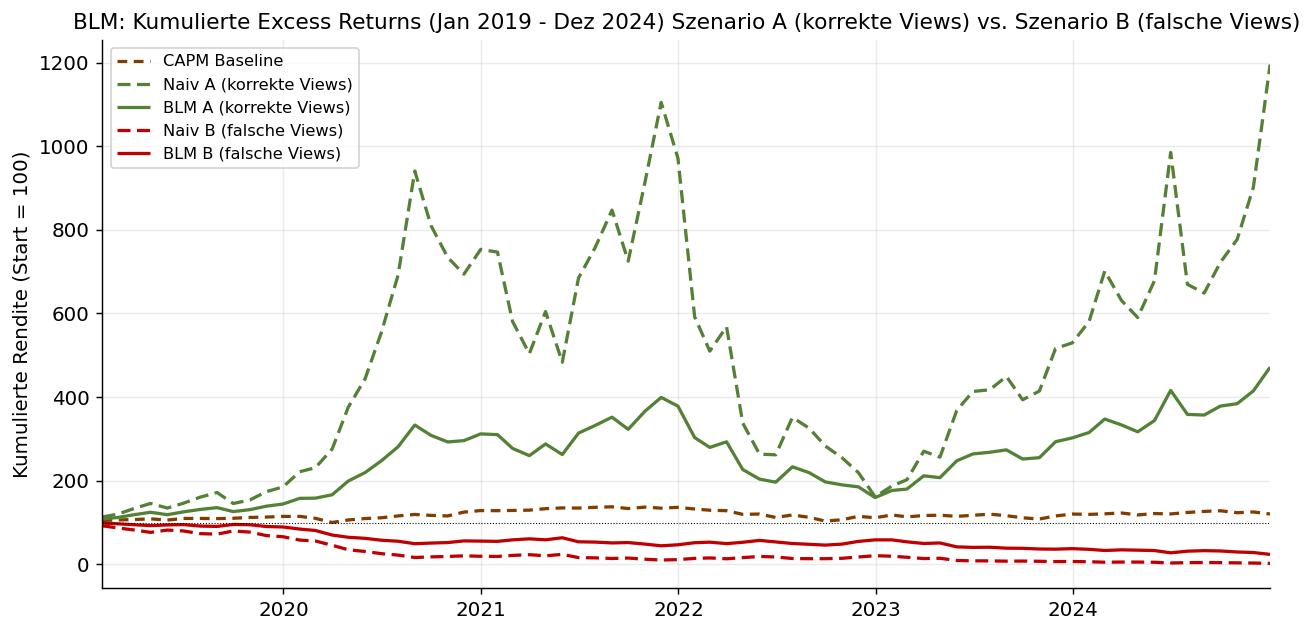

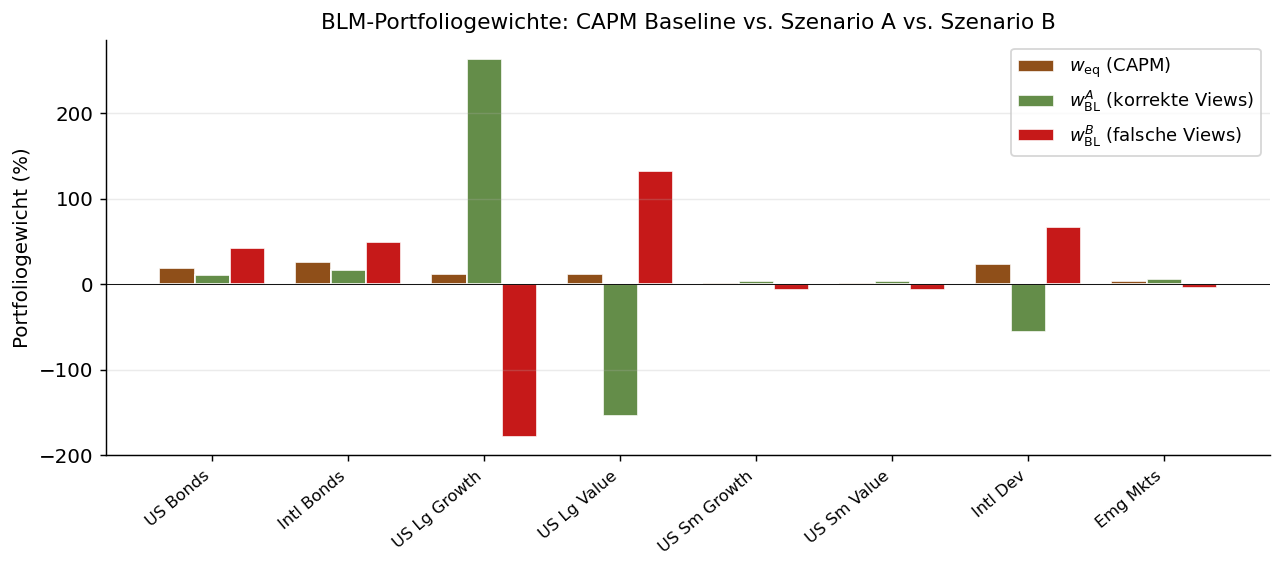

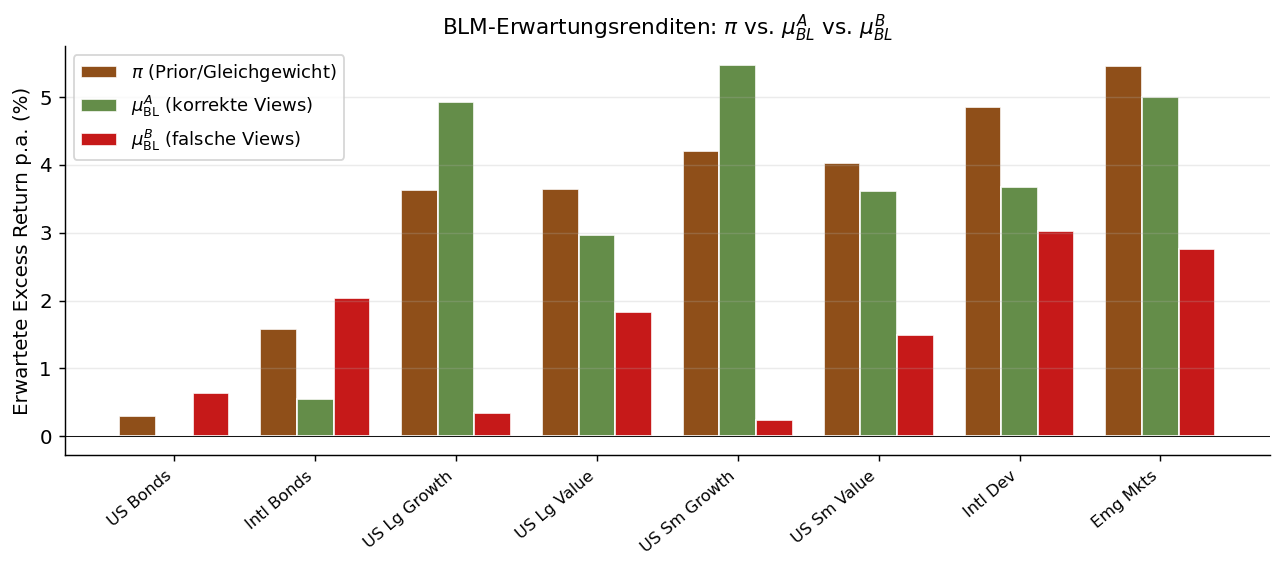

In [5]:
# Plot 1: Kumulierte Excess Returns - alle 5 Portfolios
fig, ax = plt.subplots(figsize=(10, 5))
PCOLS = {
    "CAPM Baseline":          (C[4], (3, 2)),
    "Naiv A (korrekte Views)": (C[2], (4, 2)),
    "BLM A (korrekte Views)":  (C[2], (1, 0)),
    "Naiv B (falsche Views)":  (C[1], (4, 2)),
    "BLM B (falsche Views)":   (C[1], (1, 0)),
}
for name, ret in portfolios.items():
    cr = cumulative_returns(ret) * 100
    col, dsh = PCOLS[name]
    ax.plot(cr.index, cr.values, label=name, color=col, dashes=dsh, lw=1.8)
ax.axhline(100, color="black", lw=0.6, ls=":")
ax.set_title("BLM: Kumulierte Excess Returns (Jan 2019 - Dez 2024) Szenario A (korrekte Views) vs. Szenario B (falsche Views)")
ax.set_ylabel("Kumulierte Rendite (Start = 100)")
ax.set_xlim(returns_test.index[0], returns_test.index[-1])
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
display(fig); plt.close(fig)

# Plot 2: BLM-Portfoliogewichte - Szenarien A und B im Vergleich
x, bw = np.arange(len(assets)), 0.26
sl = [SHORT[t] for t in assets]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - bw, w_eq.values * 100, bw, label=r"$w_\mathrm{eq}$ (CAPM)", color=C[4], alpha=0.9, edgecolor="white")
ax.bar(x,      res_A["w_BL"].values * 100, bw, label=r"$w_\mathrm{BL}^A$ (korrekte Views)", color=C[2], alpha=0.9, edgecolor="white")
ax.bar(x + bw, res_B["w_BL"].values * 100, bw, label=r"$w_\mathrm{BL}^B$ (falsche Views)",  color=C[1], alpha=0.9, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(sl, rotation=40, ha="right", fontsize=9)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("BLM-Portfoliogewichte: CAPM Baseline vs. Szenario A vs. Szenario B")
ax.set_ylabel("Portfoliogewicht (%)")
ax.legend(); ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
display(fig); plt.close(fig)

# Plot 3: BLM-Erwartungsrenditen - π vs. μ_BL^A vs. μ_BL^B
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - bw, pi.values * 100, bw, label=r"$\pi$ (Prior/Gleichgewicht)", color=C[4], alpha=0.9, edgecolor="white")
ax.bar(x,      res_A["mu_BL"].values * 100, bw, label=r"$\mu_\mathrm{BL}^A$ (korrekte Views)", color=C[2], alpha=0.9, edgecolor="white")
ax.bar(x + bw, res_B["mu_BL"].values * 100, bw, label=r"$\mu_\mathrm{BL}^B$ (falsche Views)",  color=C[1], alpha=0.9, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(sl, rotation=40, ha="right", fontsize=9)
ax.axhline(0, color="black", lw=0.5)
ax.set_title(r"BLM-Erwartungsrenditen: $\pi$ vs. $\mu_{BL}^A$ vs. $\mu_{BL}^B$")
ax.set_ylabel("Erwartete Excess Return p.a. (%)")
ax.legend(); ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
display(fig); plt.close(fig)

---
## §4.6.1 · Parametersensitivität (τ und c)

In [6]:
# Grid: tau x c
T           = len(excess_train)
TAU_VALUES  = [1 / T, 0.01, 0.05]
TAU_LABELS  = [f"1/T ({1/T:.3f})", "0.01", "0.05"]
C_VALUES    = [0.30, 0.50, 0.70]
C_LABELS    = ["c = 0.30", "c = 0.50", "c = 0.70"]

def make_views_sens(asset_names, confidence):
    vs = ViewSet(asset_names=asset_names)
    vs.add_relative(outperform=["IWF","IWD","IWO","IWN","EFA","EEM"], underperform=["AGG","BWX"],
                    expected_diff=0.05, confidence=confidence, label="Aktien > Anleihen: +5% p.a.")
    vs.add_relative(outperform=["IWF"], underperform=["IWD"],
                    expected_diff=0.04, confidence=confidence, label="IWF > IWD: +4% p.a.")
    vs.add_relative(outperform=["IWF","IWD"], underperform=["EFA"],
                    expected_diff=0.02, confidence=confidence, label="US > EFA: +2% p.a.")
    return vs

records = []
for ti, (tau, tlabel) in enumerate(zip(TAU_VALUES, TAU_LABELS)):
    for ci, (c, clabel) in enumerate(zip(C_VALUES, C_LABELS)):
        vs = make_views_sens(assets, c)
        P, Q, Omega = vs.build(Sigma=Sigma, tau=tau, omega_method="idzorek")
        result = run_blm(Sigma, w_eq, P, Q, Omega, delta=delta, tau=tau)
        mu_BL  = result["mu_BL"]
        w_BL   = result["w_BL"]
        exc_test = returns_test.sub(rf_test, axis=0)
        ret_bl   = backtest_ret = (exc_test * w_BL).sum(axis=1)
        perf   = performance_summary({"BLM": ret_bl}, frequency=12)
        sharpe = float(perf.at["BLM", "Sharpe Ratio"])
        rec = {"tau": tau, "tau_label": tlabel, "tau_idx": ti,
               "c": c, "c_label": clabel, "c_idx": ci, "sharpe": sharpe}
        for t in assets:
            rec[f"mu_{t}"] = mu_BL[t] * 100
            rec[f"w_{t}"]  = w_BL[t]  * 100
        records.append(rec)
        print(f"  tau={tlabel:12s}, {clabel}: w_IWF={w_BL['IWF']*100:+7.1f}%  mu_IWF={mu_BL['IWF']*100:+5.2f}%  Sharpe={sharpe:.3f}")

df_sens = pd.DataFrame(records)

  tau=1/T (0.008) , c = 0.30: w_IWF= +165.1%  mu_IWF=+4.38%  Sharpe=0.908
  tau=1/T (0.008) , c = 0.50: w_IWF= +270.4%  mu_IWF=+4.93%  Sharpe=0.948
  tau=1/T (0.008) , c = 0.70: w_IWF= +378.5%  mu_IWF=+5.54%  Sharpe=0.957
  tau=0.01        , c = 0.30: w_IWF= +164.8%  mu_IWF=+4.38%  Sharpe=0.908
  tau=0.01        , c = 0.50: w_IWF= +270.0%  mu_IWF=+4.93%  Sharpe=0.948
  tau=0.01        , c = 0.70: w_IWF= +378.1%  mu_IWF=+5.54%  Sharpe=0.957
  tau=0.05        , c = 0.30: w_IWF= +159.9%  mu_IWF=+4.38%  Sharpe=0.909
  tau=0.05        , c = 0.50: w_IWF= +264.0%  mu_IWF=+4.93%  Sharpe=0.950
  tau=0.05        , c = 0.70: w_IWF= +372.6%  mu_IWF=+5.54%  Sharpe=0.959


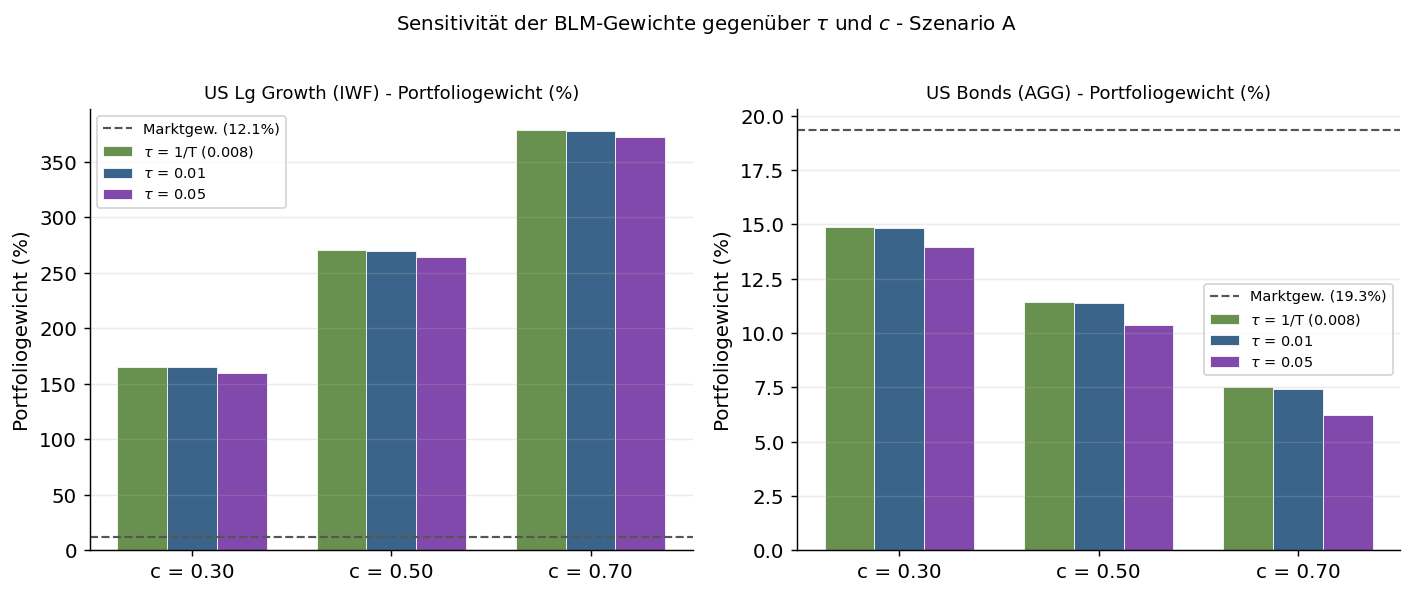

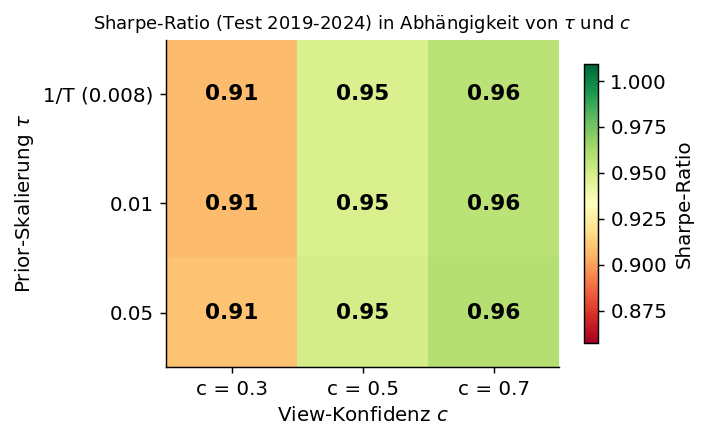

In [7]:
# Plot: IWF- und AGG-Gewicht für alle (tau, c)-Paare
COLORS_TAU = [C[2], C[0], C[3]]
x     = np.arange(len(C_VALUES))
bar_w = 0.25
highlight = [("IWF", "US Lg Growth (IWF) - Portfoliogewicht (%)"),
             ("AGG", "US Bonds (AGG) - Portfoliogewicht (%)")]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (asset, title) in zip(axes, highlight):
    eq_w = float(w_eq.loc[asset] * 100)
    for ti, (tlabel, color) in enumerate(zip(TAU_LABELS, COLORS_TAU)):
        subset = df_sens[df_sens.tau_idx == ti].sort_values("c_idx")
        vals   = subset[f"w_{asset}"].tolist()
        ax.bar(x + (ti - 1) * bar_w, vals, bar_w,
               label=r"$\tau$ = " + tlabel, color=color, alpha=0.88, edgecolor="white", linewidth=0.5)
    ax.axhline(eq_w, color="#555555", lw=1.2, ls="--", label=f"Marktgew. ({eq_w:.1f}%)")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels(C_LABELS)
    ax.set_title(title, fontsize=10); ax.set_ylabel("Portfoliogewicht (%)")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.25)
fig.suptitle(r"Sensitivität der BLM-Gewichte gegenüber $\tau$ und $c$ - Szenario A", fontsize=11, y=1.01)
plt.tight_layout()
display(fig); plt.close(fig)

# Plot: Sharpe-Ratio als Heatmap
sharpe_mat = np.zeros((len(TAU_VALUES), len(C_VALUES)))
for rec in records:
    sharpe_mat[rec["tau_idx"], rec["c_idx"]] = rec["sharpe"]

fig, ax = plt.subplots(figsize=(5.5, 3.5))
im = ax.imshow(sharpe_mat, cmap="RdYlGn", aspect="auto",
               vmin=sharpe_mat.min()-0.05, vmax=sharpe_mat.max()+0.05)
ax.set_xticks(range(len(C_VALUES))); ax.set_xticklabels([f"c = {c}" for c in C_VALUES])
ax.set_yticks(range(len(TAU_VALUES))); ax.set_yticklabels(TAU_LABELS)
ax.set_xlabel("View-Konfidenz $c$"); ax.set_ylabel(r"Prior-Skalierung $\tau$")
ax.set_title(r"Sharpe-Ratio (Test 2019-2024) in Abhängigkeit von $\tau$ und $c$", fontsize=10)
for i in range(len(TAU_VALUES)):
    for j in range(len(C_VALUES)):
        ax.text(j, i, f"{sharpe_mat[i,j]:.2f}", ha="center", va="center", fontsize=12, fontweight="bold")
plt.colorbar(im, ax=ax, shrink=0.85, label="Sharpe-Ratio")
plt.tight_layout()
display(fig); plt.close(fig)

---
## §4.6.2 · Normalverteilungsannahme & Fat Tails

In [8]:
# Deskriptive Statistiken der monatlichen Excess Returns (Trainingsperiode)
from matplotlib.lines import Line2D

norm_records = []
for t in assets:
    r = excess_train[t].dropna().values
    mu_r    = r.mean()
    sigma_r = r.std(ddof=1)
    skew    = stats.skew(r)
    kurt    = stats.kurtosis(r, fisher=True)
    jb_stat, jb_p = stats.jarque_bera(r)
    var_emp    = float(np.percentile(r, 5))
    var_normal = float(mu_r - 1.645 * sigma_r)
    norm_records.append({
        "Ticker": t, "Anlageklasse": LABELS[t],
        "Mittelwert (%)": mu_r * 100, "Volatilität (%)": sigma_r * 100,
        "Schiefe": skew, "Überschuss-Kurtosis": kurt,
        "JB-Statistik": jb_stat, "JB p-Wert": jb_p,
        "VaR 5% empirisch (%)": var_emp * 100,
        "VaR 5% normal (%)": var_normal * 100,
        "VaR-Differenz (pp)": (var_emp - var_normal) * 100,
    })

df_norm = pd.DataFrame(norm_records).set_index("Ticker")
print("Deskriptive Statistiken (Trainingsperiode 2008-2018):")
print(f"{'Ticker':5}  {'Schiefe':>8}  {'Ex-Kurt':>8}  {'JB p':>8}  {'VaR emp%':>10}  {'VaR norm%':>10}")
for t in assets:
    row  = df_norm.loc[t]
    star = "***" if row["JB p-Wert"] < 0.01 else "**" if row["JB p-Wert"] < 0.05 else "*" if row["JB p-Wert"] < 0.10 else "   "
    print(f"{t:5}  {row['Schiefe']:>8.3f}  {row['Überschuss-Kurtosis']:>8.3f}  "
          f"{row['JB p-Wert']:>8.3f}{star}  {row['VaR 5% empirisch (%)']:>10.2f}  {row['VaR 5% normal (%)']:>10.2f}")

Deskriptive Statistiken (Trainingsperiode 2008-2018):
Ticker   Schiefe   Ex-Kurt      JB p    VaR emp%   VaR norm%
AGG       1.005     5.180     0.000***       -1.39       -1.61
BWX      -0.152     0.738     0.174          -4.41       -4.02
IWF      -0.746     1.652     0.000***       -7.62       -6.61
IWD      -0.734     1.637     0.000***       -8.09       -6.90
IWO      -0.618     1.242     0.000***      -10.40       -8.85
IWN      -0.558     1.460     0.000***       -9.13       -8.69
EFA      -0.404     1.186     0.003***      -10.51       -8.87
EEM      -0.162     1.508     0.001***       -9.32      -10.72


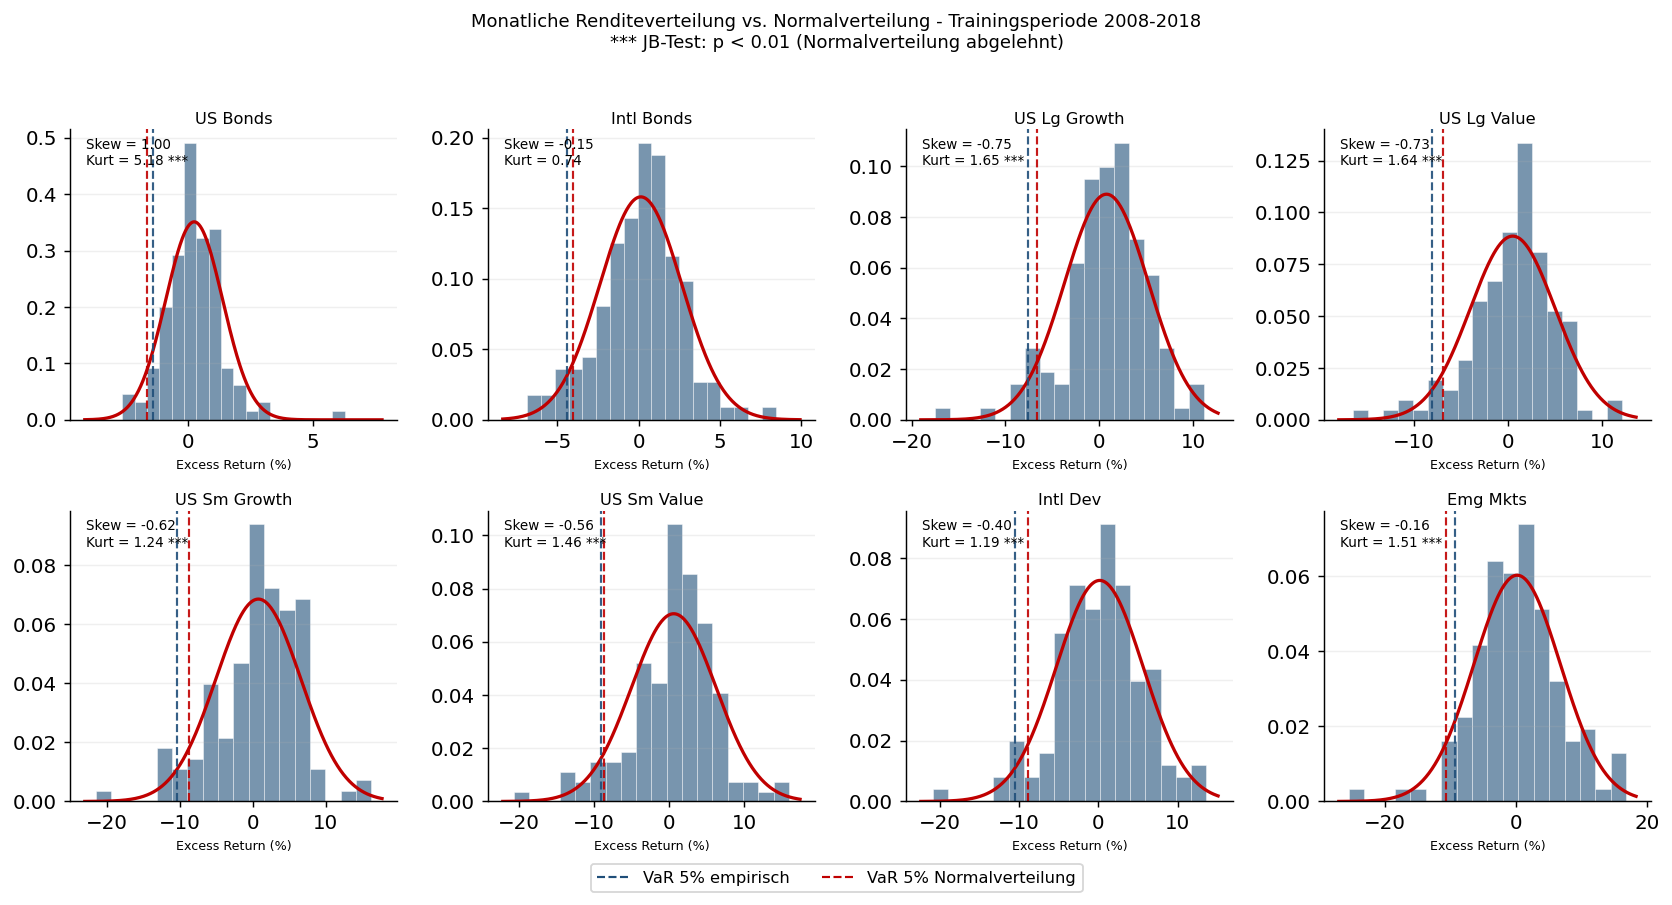

In [9]:
# Plot: Histogramme aller 8 ETFs mit Normalverteilungs-Overlay
SHORT = {t: v.split(" (")[0] for t, v in LABELS.items()}
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
axes_flat = axes.flatten()

for i, t in enumerate(assets):
    ax = axes_flat[i]
    r  = excess_train[t].dropna().values * 100
    mu_r, sig_r = r.mean(), r.std(ddof=1)
    row = df_norm.loc[t]
    ax.hist(r, bins=18, density=True, alpha=0.60, color=C[0], edgecolor="white", linewidth=0.4)
    x_lin = np.linspace(r.min()-1.5, r.max()+1.5, 400)
    ax.plot(x_lin, stats.norm.pdf(x_lin, mu_r, sig_r), color=C[1], lw=1.8)
    var_emp    = np.percentile(r, 5)
    var_normal = mu_r - 1.645 * sig_r
    ax.axvline(var_emp,    color=C[0], lw=1.2, ls="--", alpha=0.9)
    ax.axvline(var_normal, color=C[1], lw=1.2, ls="--", alpha=0.9)
    jb_p = row["JB p-Wert"]
    star = "***" if jb_p < 0.01 else "**" if jb_p < 0.05 else "*" if jb_p < 0.10 else ""
    ax.annotate(f"Skew = {row['Schiefe']:.2f}\nKurt = {row['Überschuss-Kurtosis']:.2f} {star}",
                xy=(0.05, 0.97), xycoords="axes fraction", va="top", ha="left", fontsize=7.5)
    ax.set_title(SHORT[t], fontsize=9, pad=3)
    ax.set_xlabel("Excess Return (%)", fontsize=7)
    ax.grid(axis="y", alpha=0.2)

legend_handles = [
    Line2D([0],[0], color=C[0], lw=1.2, ls="--", label="VaR 5% empirisch"),
    Line2D([0],[0], color=C[1], lw=1.2, ls="--", label="VaR 5% Normalverteilung"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Monatliche Renditeverteilung vs. Normalverteilung - Trainingsperiode 2008-2018\n*** JB-Test: p < 0.01 (Normalverteilung abgelehnt)", fontsize=10, y=1.02)
plt.tight_layout()
display(fig); plt.close(fig)